<a href="https://colab.research.google.com/github/VIAMRSH123/ML-Lab/blob/main/Lab-7/Svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.70      0.54      0.61        13
           2       0.62      0.77      0.69        13

    accuracy                           0.80        45
   macro avg       0.78      0.77      0.77        45
weighted avg       0.81      0.80      0.80        45


Confusion Matrix:
 [[19  0  0]
 [ 0  7  6]
 [ 0  3 10]]


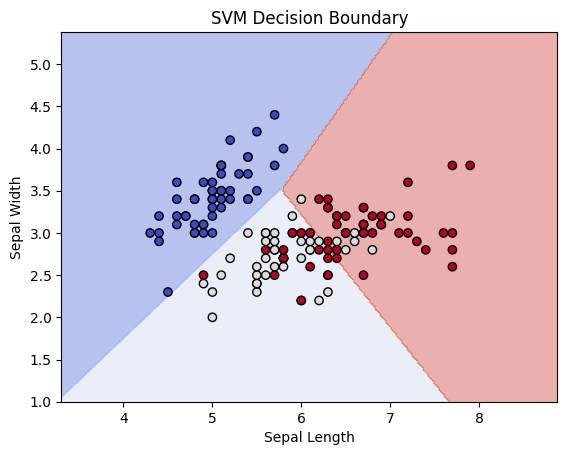


--- RBF Kernel Results ---
Accuracy: 0.8


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load Dataset (Built-in)
iris = datasets.load_iris()

# Features and Labels
X = iris.data[:, :2]   # Using first 2 features for visualization
y = iris.target

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 4. Train SVM Model
model = SVC(kernel='linear')  # Try 'rbf' or 'poly'
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 7. Decision Boundary Visualization
def plot_decision_boundary(X, y, model):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.xlabel("Sepal Length")
    plt.ylabel("Sepal Width")
    plt.title("SVM Decision Boundary")
    plt.show()

plot_decision_boundary(X, y, model)

# 8. Try RBF Kernel
model_rbf = SVC(kernel='rbf', gamma='scale')
model_rbf.fit(X_train, y_train)

y_pred_rbf = model_rbf.predict(X_test)

print("\n--- RBF Kernel Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))